In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

In [ ]:
df = pd.read_csv("fire_incident.csv", encoding='latin1')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])

In [ ]:
monthly_data = df.groupby(pd.Grouper(key='Date', freq='ME')).size()

In [ ]:
# Keep only 2022
monthly_data = monthly_data[monthly_data.index.year == 2022]

In [ ]:
full_range = pd.date_range('2022-01-01', '2022-12-31', freq='ME')
monthly_data = monthly_data.reindex(full_range, fill_value=0)
monthly_data.index = monthly_data.index.strftime('%Y-%m')

print("2022 Monthly Fire Incidents:")
print(monthly_data)

2022 Monthly Fire Incidents:
2022-01    0
2022-02    0
2022-03    0
2022-04    0
2022-05    0
2022-06    0
2022-07    0
2022-08    0
2022-09    0
2022-10    0
2022-11    0
2022-12    0
dtype: int64


In [ ]:
# 70/30 Split
split = int(len(monthly_data) * 0.7)
train = monthly_data.iloc[:split]
test = monthly_data.iloc[split:]

print(f"\n70/30 Split → Train: {len(train)} months | Test: {len(test)} months")


70/30 Split → Train: 8 months | Test: 4 months


In [ ]:
print("Training auto_arima...")
model = auto_arima(
    train,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=1, D=0, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
forecast = model.predict(n_periods=len(test))

Training auto_arima...
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-167.504, Time=0.02 sec
Total fit time: 0.016 seconds


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/auto.py:444: UserWarning: Input time-series is completely constant; returning a (0, 0, 0) ARMA.
  warnings.warn('Input time-series is completely constant; '


In [ ]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / (test + 1))) * 100

print(f"\n70/30 RESULTS:")
print(f"MAE  : {mae:.2f} incidents")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.1f}%")

print(model.summary())


70/30 RESULTS:
MAE  : 0.00 incidents
RMSE : 0.00
MAPE : nan%
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    8
Model:                        SARIMAX   Log Likelihood                  84.752
Date:                Thu, 18 Dec 2025   AIC                           -167.504
Time:                        15:25:35   BIC                           -167.424
Sample:                    01-01-2022   HQIC                          -168.040
                         - 08-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2          1e-10   7.01e-10      0.143      0.887   -1.27e-09    1.47e-09
Ljung-Box (L1) (Q):                    nan   Jarque-Bera (JB):       

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1431: RuntimeWarning: invalid value encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


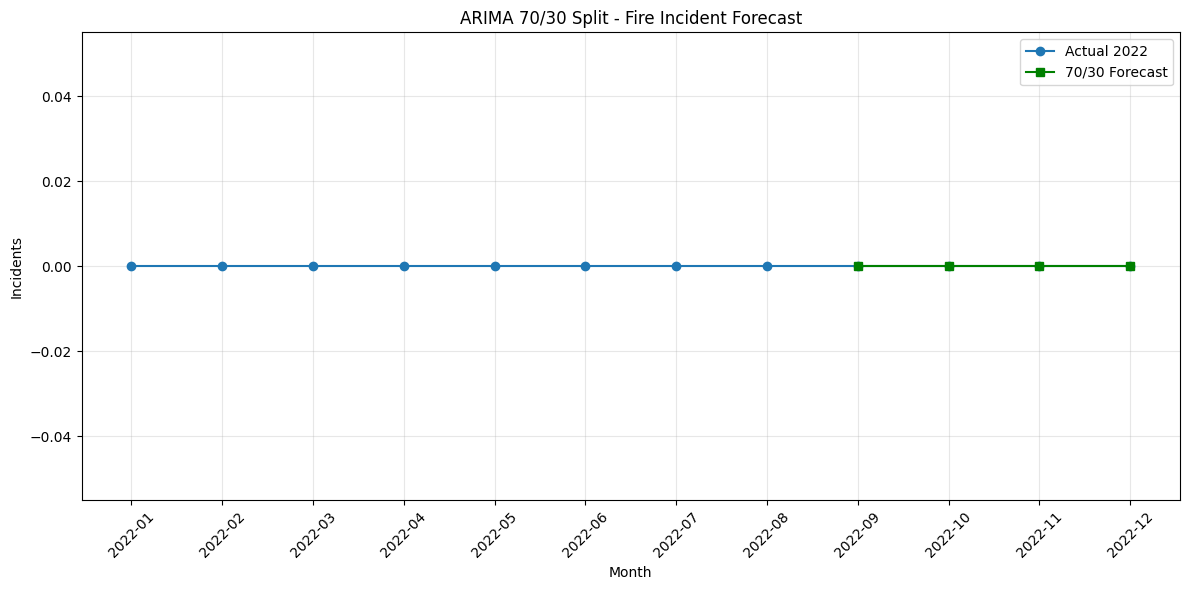

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_data.index, monthly_data.values, label='Actual 2022', marker='o')
plt.plot(test.index, forecast, label='70/30 Forecast', marker='s', color='green')
plt.title('ARIMA 70/30 Split - Fire Incident Forecast')
plt.xlabel('Month'); plt.ylabel('Incidents')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [ ]:
with open('fire_forecast_70_30.pkl', 'wb') as f:
    pickle.dump(model, f)